In [1]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [2]:
from torchcfm.conditional_flow_matching import *
from torchdyn.core import NeuralODE
from torchcfm.utils import plot_trajectories, torch_wrapper

In [3]:
from torchdiffeq import odeint
from torchcfm.optimal_transport import wasserstein

In [4]:
import matplotlib.pyplot as plt
from matplotlib import cm

In [5]:
device = 'cuda:3'

In [6]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [7]:
coords = adata.obsm[cellstate_key]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm[f"{cellstate_key}_standardized"] = coords

In [8]:
cellstate_key = "DM_EigenVectors_multiscaled"
timepoint_key = 'timepoint_tx_days'

In [9]:
larry = sc.read_h5ad("data/Weinreb2020_fate_prediction.h5ad")
adata = sc.read_h5ad("data/klein_subset.h5ad")
Fate_bias = pd.read_csv("data/Weinreb/F_obs.csv", index_col=0)
Fate_bias.index = Fate_bias.index.astype(str)

overlapped_cbs = np.intersect1d(Fate_bias.index, adata.obs_names)

In [21]:
adata

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'palantir_pseudotime', 'palantir_entropy'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'X_diffmap', 'X_pca', 'X_umap', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [22]:
adata.obs['Annotation'].nunique()

11

In [11]:
X_t0 = adata[overlapped_cbs].obsm[cellstate_key].copy()

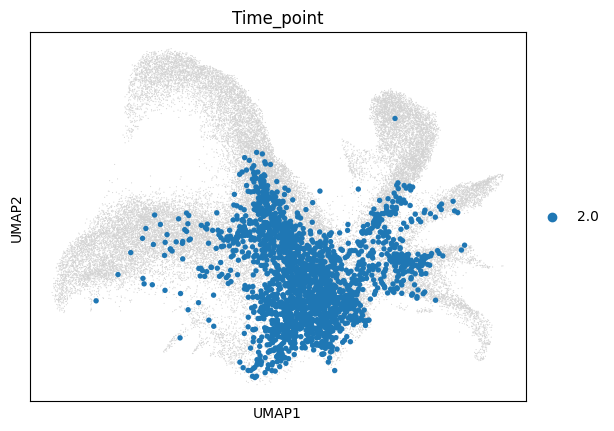

In [14]:
fig = sc.pl.umap(adata, show=False, return_fig=True)
sc.pl.umap(adata[overlapped_cbs], color='Time_point', ax=fig.gca())

In [18]:
import annoy

In [29]:
cellstate = adata.obsm[cellstate_key]
n_trees = 10
idx = annoy.AnnoyIndex(cellstate.shape[1], "euclidean")

[idx.add_item(i, cellstate[i]) for i in range(len(adata))]
idx.build(n_trees)

DM = torch.Tensor(adata[overlapped_cbs].obsm[cellstate_key].toarray())
print(DM.shape)

torch.Size([1989, 5])


In [67]:
def assign_celltype(X_t1, n_neighbors=20, cellstate='Annotation'):
    # nn = idx.get_nns_by_vector(X_t1, n_neighbors)
    # query_df = pd.DataFrame(adata[nn].obs['Annotation'].to_numpy().reshape(-1, n_neighbors)).T

    nn = np.array(
        [idx.get_nns_by_vector(X_t1[i], n_neighbors) for i in range(len(X_t1))]
    ).flatten()
    query_df = pd.DataFrame(adata[nn].obs[cellstate].to_numpy().reshape(-1, n_neighbors)).T
    return query_df

# PINN v

In [15]:
ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=20-total_loss=0.21981135.ckpt"

model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"PINN.models.{model_name}")

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


In [16]:
cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

In [17]:
def v_ode(t, state):
    s_in = state
    t_in = torch.full((s_in.shape[0],), t.item()).float().to(s_in.device)
    # dsdt
    return pde_model.v(s_in, t_in) 

In [48]:
t_list = adata.uns['pop']['t'] 
t_list = t_list / t_list[0]


s_in = torch.tensor(X_t0).to(device).float()

with torch.no_grad():
    s_t = odeint(v_ode, 
                y0 = s_in, 
                t = torch.linspace(1, 3, 2),
                atol = 1e-8,
                rtol = 1e-8,
                method = 'dopri5')
    traj = s_t.detach().cpu().numpy()

In [51]:
traj.shape

(2, 1989, 5)

In [76]:
adata.obs['Annotation'].unique()

['undiff', 'Monocyte', 'Neutrophil', 'Baso', 'Erythroid', ..., 'Mast', 'Lymphoid', 'Eos', 'Ccr7_DC', 'pDC']
Length: 11
Categories (11, object): ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', ..., 'Monocyte', 'Neutrophil', 'pDC', 'undiff']

In [77]:
qeury_df = assign_celltype(traj[-1])

In [91]:
dfs = []
for i in range(len(overlapped_cbs)):
    series = pd.Categorical(
        qeury_df[i].values, categories=adata.obs['Annotation'].unique(), ordered=False
    )
    dfs.append(series.value_counts())

In [96]:
df = pd.concat(dfs, axis=1)
df.columns = overlapped_cbs
df = df.T

In [97]:
df

,Baso,Ccr7_DC,Eos,Erythroid,Lymphoid,Mast,Meg,Monocyte,Neutrophil,pDC,undiff
13199,0,0,0,0,0,0,0,0,17,0,3
13210,0,0,0,0,0,0,0,0,18,0,2
13226,0,0,0,0,0,2,0,0,0,0,18
13235,0,0,0,0,0,3,0,0,0,0,17
13256,0,0,0,0,0,0,0,0,20,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69312,0,0,0,0,0,0,0,0,20,0,0
69313,0,0,0,0,0,1,1,0,0,0,18
69317,0,0,0,0,0,0,0,0,20,0,0
69322,0,0,0,0,0,0,0,0,8,0,12


In [89]:
dfs[0].value_counts()

Baso           0
Ccr7_DC        0
Eos            0
Erythroid      0
Lymphoid       0
Mast           0
Meg            0
Monocyte       0
Neutrophil    17
pDC            0
undiff         3
Name: count, dtype: int64

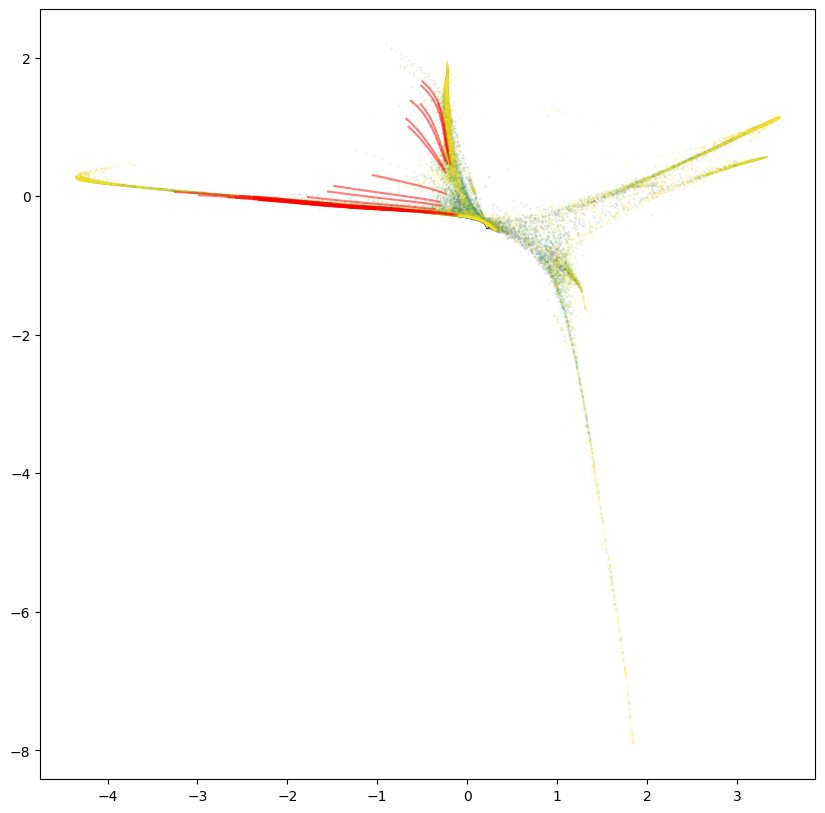

In [93]:
which_dim = [0,2]

w_idx = np.arange(traj.shape[1])
distance_by_i = np.array([wasserstein(traj[-1][[i]], torch.tensor(test_X[starting_i+1]), power=2, method='exact') for i in w_idx])
sorted_idx = [x for _, x in sorted(zip(distance_by_i, w_idx))]

fig, ax = plot_allcells_and_trajectories(traj.cpu().numpy(),
                                highlight_idx=range(30),
                            which_dim=which_dim)
fig.show()

# load TIGON model

In [51]:
# git clone TIGON 
sys.path.append('/ssd/users/Wergillius/Project/TIGON')
import utility

In [ ]:
timepoints = [0.5, 1.0, 1.5]

In [10]:
ckpt = torch.load("logs/TIGON/model2/ckpt.pth")

In [12]:
LOSS = ckpt['LOSS']
Trans = ckpt['TRANS']
L2_1 = ckpt['L2_1']
L2_2 = ckpt['L2_2']
Sigma = ckpt['Sigma']

In [16]:
LOSS[80],LOSS[100]

(0.5170110464096069, 8.993673324584961)

In [18]:
best_checkpoint = torch.load("logs/TIGON/model2/ckpt_itr80.pth")
model_state_dict = best_checkpoint['func_state_dict']

In [ ]:
device = 'cuda:3'

func = utility.UOT(in_out_dim=n_dimension, 
           hidden_dim=16, n_hiddens=4, activation='Tanh').to(device)
func.load_state_dict(model_state_dict)

v = func.hyper_net1.to(device)
g = func.hyper_net2.to(device)

In [43]:
torch.from_numpy(test_X[0]).float().to(device).shape

torch.Size([4, 5])

In [54]:
node = NeuralODE(v, solver="dopri5", sensitivity="adjoint")

In [ ]:
with torch.no_grad():
    traj_0_1 = odeint(v,  y0 = torch.from_numpy(test_X[0]).float().to(device), 
              t = torch.linspace(0.5, 1.0, 2), method='dopri5'
              ).cpu()


wasserstein(traj_0_1[-1], torch.tensor(test_X[1]), power=2)

1.115632052657166

In [212]:
with torch.no_grad():
    traj_1_2 = odeint(v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(1, 1.5, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.457949849823799
W2 skh reg=0.01: 	 0.01159203084823636
W2 skh reg=0.05: 	 3.4819759527116725
W2 skh reg=1: 	 3.6565807834299573


In [222]:
with torch.no_grad():
    traj_1_2 = odeint(v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(4.0, 6.0, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.493203880399981
W2 skh reg=0.01: 	 0.001563985608908302
W2 skh reg=0.05: 	 3.516798497486617
W2 skh reg=1: 	 3.689562078316061


In [ ]:
wasserstein

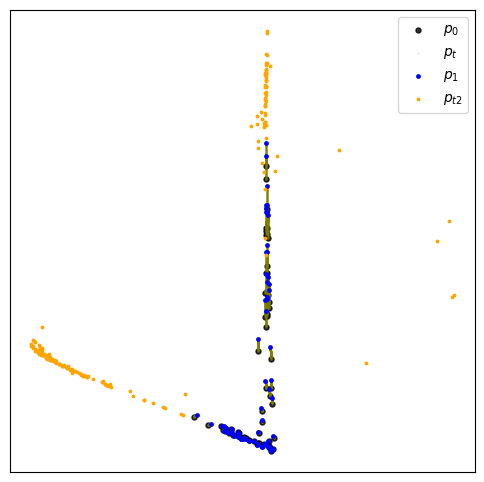

In [193]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

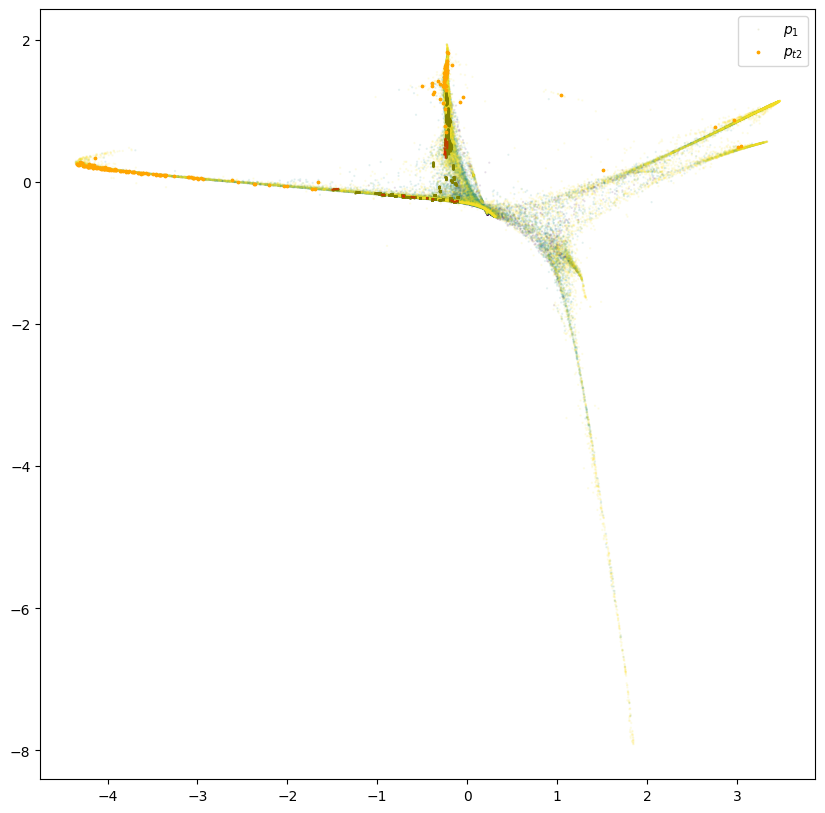

In [194]:
which_dim = [0,2]
fig, ax = plot_allcells_and_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

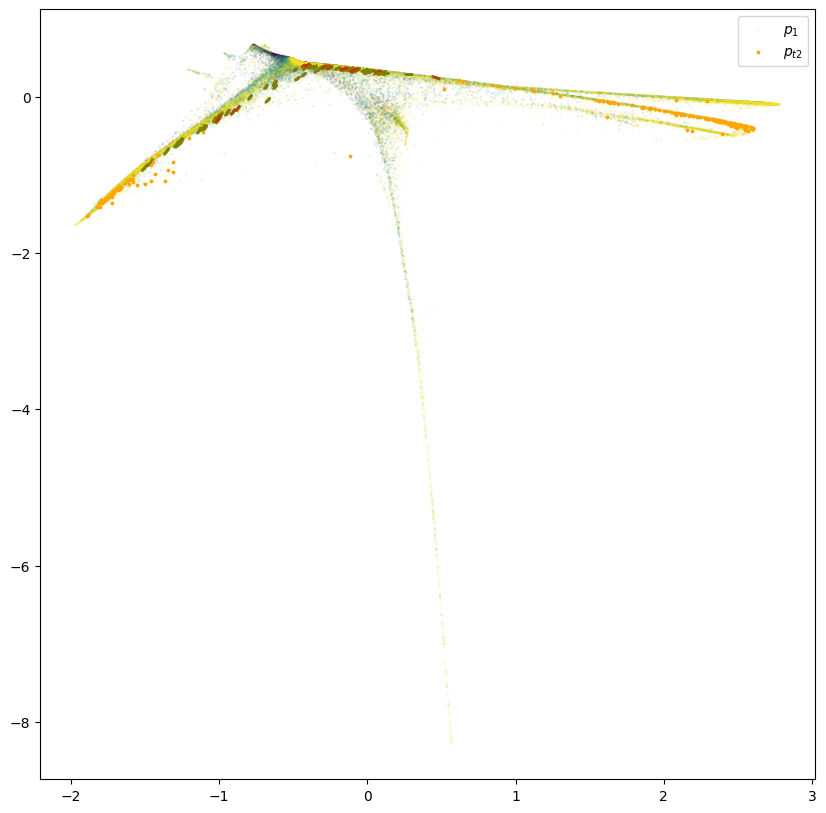

In [195]:
which_dim = [1,3]
fig, ax = plot_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

# OT_cfm model

In [217]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_ot_cfm_.pt")
ot_cfm_model = checkpoint['model'].to(device)

In [218]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(test_X[1]).float().to(device),
        t_span=torch.linspace(1, 2, 200),
    ).cpu()

print("W2: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.069594847945499
W2 skh reg=0.01: 	 0.022653652218989042
W2 skh reg=0.05: 	 3.098471623118887
W2 skh reg=1: 	 3.2898329654586917


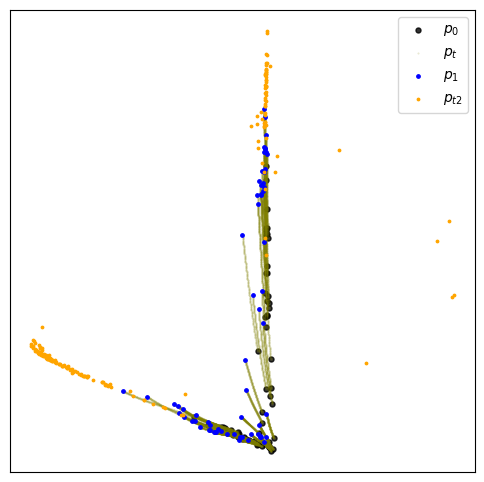

In [189]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

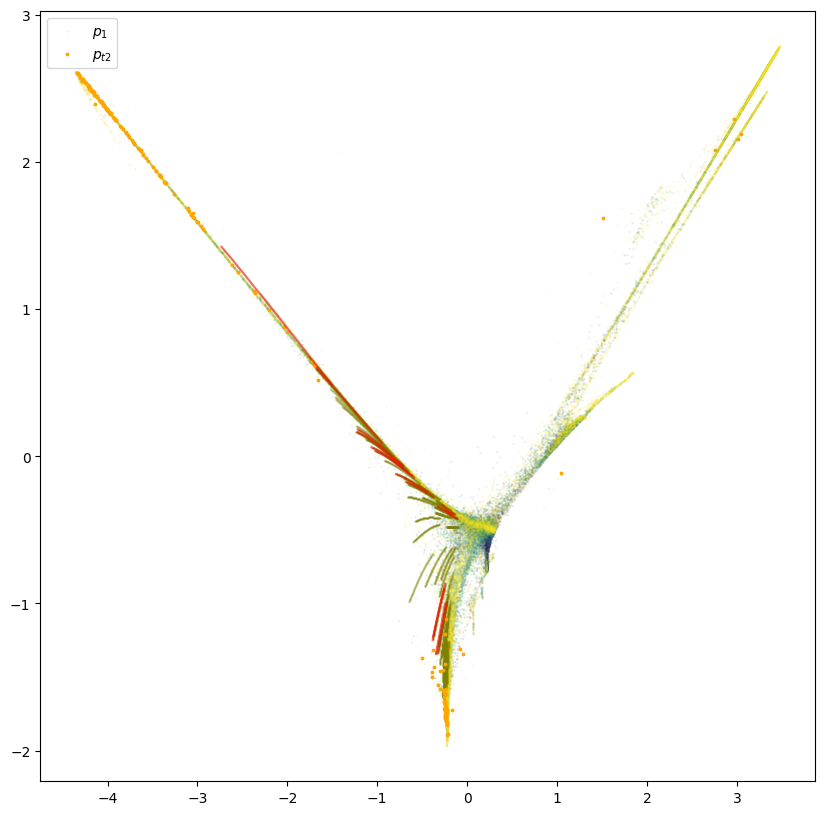

In [190]:
which_dim = [0,1]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

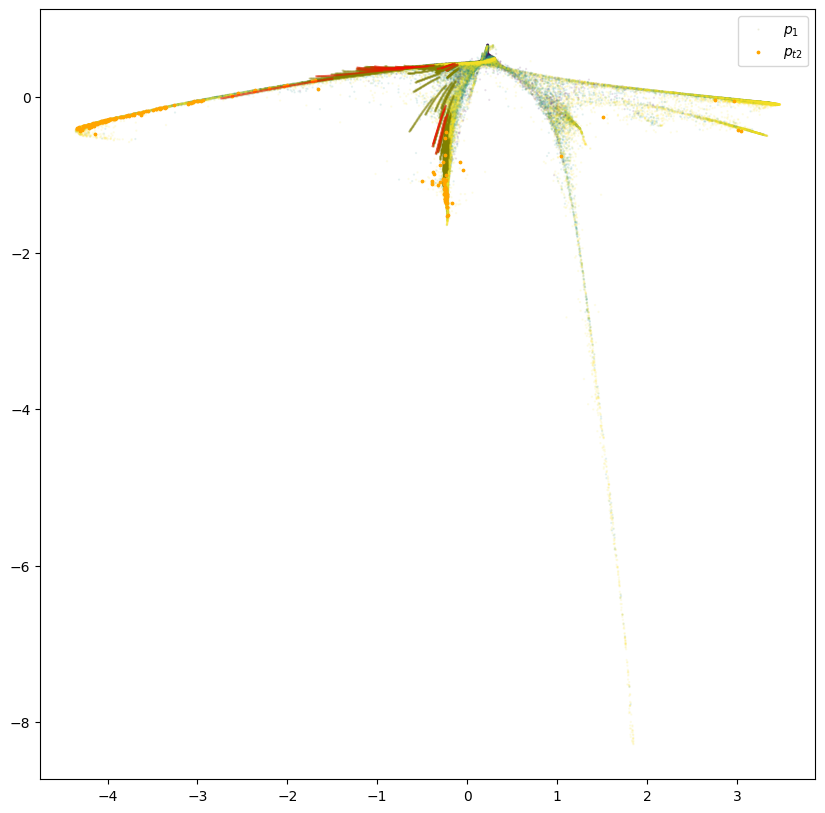

In [191]:
which_dim = [0,3]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

In [104]:
wasserstein(traj[-1], torch.tensor(test_X[1]), power=2)

1.2256528716729667

# SF2M

In [220]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_sf2m_sigma_0.25.pt")
sf2m_model = checkpoint['model'].to(device)

In [221]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(test_X[1]).float().to(device),
        t_span=torch.linspace(1, 2, 200),
    ).cpu()

print("W2: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 2.997398643204862
W2 skh reg=0.01: 	 0.02189552092846346
W2 skh reg=0.05: 	 3.026866327282345
W2 skh reg=1: 	 3.224602721316507


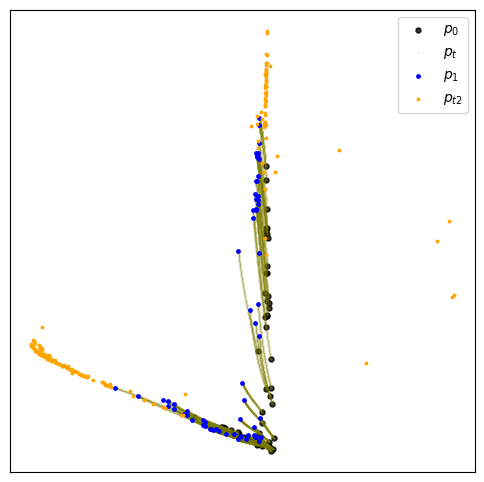

In [199]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

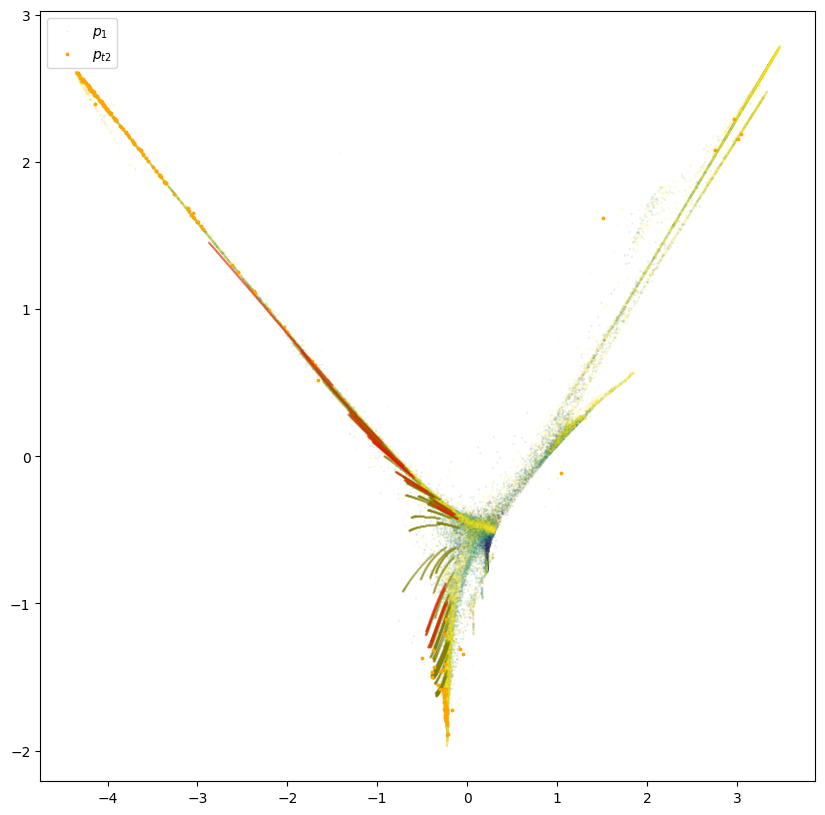

In [203]:
which_dim = [0,1]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

# PINN

In [65]:
import functools

In [66]:
from PINN import reader, models, pl, tl

In [67]:
class ODE(torch.nn.Module):
    noise_type = "diagonal"
    sde_type = "ito"

    def __init__(self, drift, ):
        super().__init__()
        self.drift = drift


    # Drift
    def forward(self, t, s):
        batch = s.shape[0]
        device = s.device
        t_in = torch.full((batch,1), t).float().to(device)

        return self.drift(s, t_in)
    

In [72]:
device = 'cuda:3'


# PINN_ckpt = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_7/checkpoints/epoch=125-total_loss=0.02699740.ckpt"
PINN_ckpt = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=20-total_loss=0.21981135.ckpt"
pde_model = PINN.models.pde_params.load_from_checkpoint(PINN_ckpt, map_location='cpu')
pde_v = ODE(pde_model.v).to(device)

In [73]:
from torchdiffeq import odeint

In [74]:
with torch.no_grad():
    traj_1_2 = odeint(pde_v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(2, 3, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 2.144477465152224
W2 skh reg=0.01: 	 0.021005106671510617
W2 skh reg=0.05: 	 2.187641239110357
W2 skh reg=1: 	 2.4392204803062016


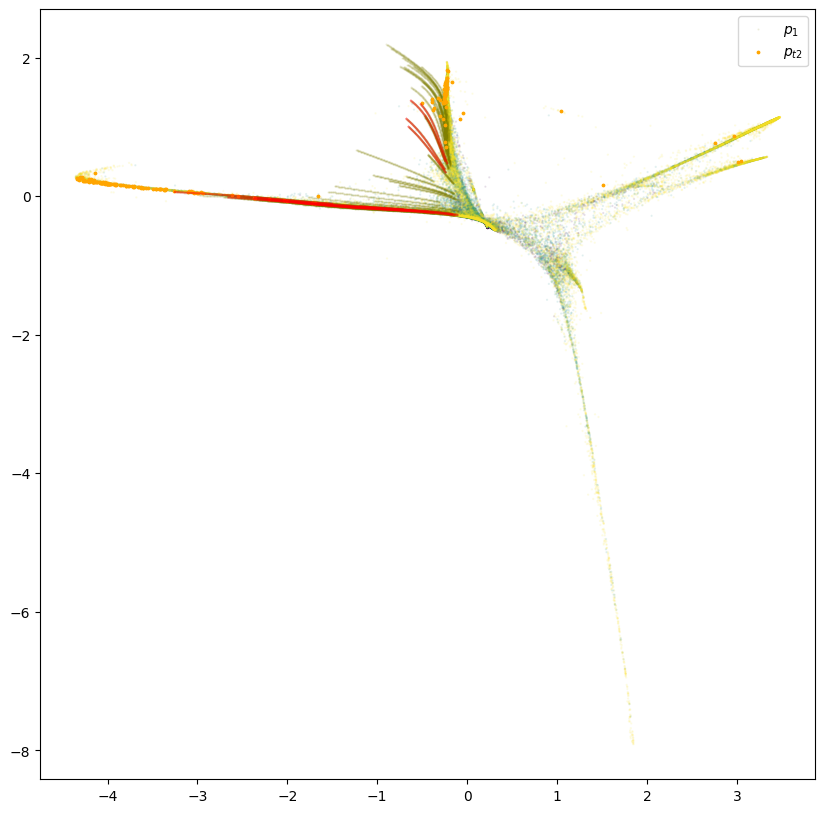

In [75]:
which_dim = [0,2]
fig, ax = plot_allcells_and_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()